#### Imports

In [997]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Enable caching (optional but speeds up repeat runs)
# fastf1.Cache.enable_cache('./cache')

#### Pull Session Data

In [998]:
def load_race_session(year, race):
    session = fastf1.get_session(year, race, 'R')
    session.load()
    return session

In [999]:
races = ['Italian Grand Prix', 'Austrian Grand Prix']

In [1000]:
sessions = []
for year in [2022, 2023, 2024]:
    for race in races:
        session = load_race_session(year, race)
        session.laps['Year'] = year  # add a year column
        session.laps['Race'] = race  # add Race column
        session.laps['LapCount'] = session.total_laps
        sessions.append(session)

# Combine all laps into one DataFrame
all_laps = pd.concat([s.laps for s in sessions], ignore_index=True)
print(f"Total laps loaded: {len(all_laps)}")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '44', '11', '4', '10', '45', '24', '31', '47', '77', '22', '6', '20', '3', '18', '14', '5']
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data

Total laps loaded: 7020


In [1001]:
all_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Year,Race,LapCount
0,0 days 01:03:59.211000,VER,1,0 days 00:01:30.827000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:30.903000,...,2022-09-11 13:03:28.378,1,4.0,False,,False,False,2022,Italian Grand Prix,53
1,0 days 01:05:25.612000,VER,1,0 days 00:01:26.401000,2.0,1.0,NaT,NaT,0 days 00:00:28.387000,0 days 00:00:29.504000,...,2022-09-11 13:04:59.452,1,3.0,False,,False,True,2022,Italian Grand Prix,53
2,0 days 01:06:51.793000,VER,1,0 days 00:01:26.181000,3.0,1.0,NaT,NaT,0 days 00:00:28.205000,0 days 00:00:29.457000,...,2022-09-11 13:06:25.853,1,3.0,False,,False,True,2022,Italian Grand Prix,53
3,0 days 01:08:17.575000,VER,1,0 days 00:01:25.782000,4.0,1.0,NaT,NaT,0 days 00:00:27.936000,0 days 00:00:29.170000,...,2022-09-11 13:07:52.034,1,3.0,False,,False,True,2022,Italian Grand Prix,53
4,0 days 01:09:43.087000,VER,1,0 days 00:01:25.512000,5.0,1.0,NaT,NaT,0 days 00:00:27.904000,0 days 00:00:29.341000,...,2022-09-11 13:09:17.816,1,2.0,False,,False,True,2022,Italian Grand Prix,53


In [1002]:
all_laps.shape

(7020, 34)

In [1003]:
all_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'LapCount'],
      dtype='object')

In [1004]:
all_laps.dtypes

Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedelta64[ns]
Sector3SessionTime    timedelta64[ns]
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
IsPersonalBest                 object
Compound                       object
TyreLife                      float64
FreshTyre                        bool
Team                           object
LapStartTime          timedelta64[ns]
LapStartDate           datetime64[ns]
TrackStatus                    object
Position    

In [1005]:
print(all_laps.iloc[0])

Time                      0 days 01:03:59.211000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:30.827000
LapNumber                                    1.0
Stint                                        1.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time                                  NaT
Sector2Time               0 days 00:00:30.903000
Sector3Time               0 days 00:00:28.827000
Sector1SessionTime                           NaT
Sector2SessionTime        0 days 01:03:30.484000
Sector3SessionTime        0 days 01:03:59.211000
SpeedI1                                    315.0
SpeedI2                                    316.0
SpeedFL                                    311.0
SpeedST                                    286.0
IsPersonalBest                             False
Compound                                    SOFT
TyreLife            

#### Filter out invalid laps

In [1006]:
def filter_valid_laps(laps):
    valid_laps = laps.copy()

    # 1. Remove pit in/out laps
    valid_laps = valid_laps[valid_laps['PitInTime'].isna() & valid_laps['PitOutTime'].isna()]

    # 2. Remove laps with SC/VSC, or yellow/red flag
    '''
    1: Track Clear
    2: Yellow flag
    4: Safety Car
    5: Red flag
    6: Virtual Safety Car deployed
    7: Virtual Safety Car ending
    '''
    if 'TrackStatus' in valid_laps.columns:
        valid_laps = valid_laps[~valid_laps['TrackStatus'].isin(['2', '4', '5', '6', '7'])]

    # 3. Remove laps with missing data
    valid_laps = valid_laps.dropna(subset=['LapTime', 'Compound'])

    return valid_laps

In [1007]:
filtered_laps = filter_valid_laps(all_laps)

print(f"Laps before filtering: {len(all_laps)}")
print(f"Laps after filtering:  {len(filtered_laps)}")

filtered_laps[['Driver', 'LapNumber', 'Stint', 'Compound', 'LapTime', 'TrackStatus', 'Year']].head(10)

Laps before filtering: 7020
Laps after filtering:  6441


,Driver,LapNumber,Stint,Compound,LapTime,TrackStatus,Year
0,VER,1.0,1.0,SOFT,0 days 00:01:30.827000,1,2022
1,VER,2.0,1.0,SOFT,0 days 00:01:26.401000,1,2022
2,VER,3.0,1.0,SOFT,0 days 00:01:26.181000,1,2022
3,VER,4.0,1.0,SOFT,0 days 00:01:25.782000,1,2022
4,VER,5.0,1.0,SOFT,0 days 00:01:25.512000,1,2022
5,VER,6.0,1.0,SOFT,0 days 00:01:25.660000,1,2022
6,VER,7.0,1.0,SOFT,0 days 00:01:25.297000,1,2022
7,VER,8.0,1.0,SOFT,0 days 00:01:25.618000,1,2022
8,VER,9.0,1.0,SOFT,0 days 00:01:25.886000,1,2022
9,VER,10.0,1.0,SOFT,0 days 00:01:25.953000,1,2022


#### Check if there is a need to filter outliers

In [1008]:
# Make a new column in seconds for easier plotting and math
filtered_laps['LapTimeSeconds'] = filtered_laps['LapTime'].dt.total_seconds()

In [1009]:
# Compute lap deltas within each stint
def compute_lap_delta(group):
    group = group.sort_values('LapNumber').copy()
    group['LapDelta'] = group['LapTimeSeconds'].diff()
    return group

# Apply to entire dataset
laps_with_deltas = filtered_laps.groupby(['Driver', 'Stint', 'Year'], group_keys=False).apply(compute_lap_delta)

# Flag laps with a large jump (e.g., delta > 10 seconds vs previous lap)
potential_outliers = laps_with_deltas[laps_with_deltas['LapDelta'] > 10]

print(f"Found {len(potential_outliers)} laps with a spike > 10s vs previous lap")
potential_outliers[['Driver', 'Year', 'Stint', 'LapNumber', 'LapTimeSeconds', 'LapDelta']]

Found 732 laps with a spike > 10s vs previous lap


,Driver,Year,Stint,LapNumber,LapTimeSeconds,LapDelta
5033,ALB,2024,1.0,3.0,86.282,13.954
5034,ALB,2024,1.0,4.0,86.527,15.021
5035,ALB,2024,1.0,5.0,86.039,14.637
5037,ALB,2024,1.0,7.0,85.990,14.154
5039,ALB,2024,1.0,9.0,85.666,14.039
...,...,...,...,...,...,...
5554,ZHO,2024,2.0,51.0,85.946,12.417
1613,ZHO,2022,3.0,57.0,89.649,19.514
4043,ZHO,2023,3.0,14.0,86.917,15.721
2789,ZHO,2023,3.0,35.0,85.983,14.342


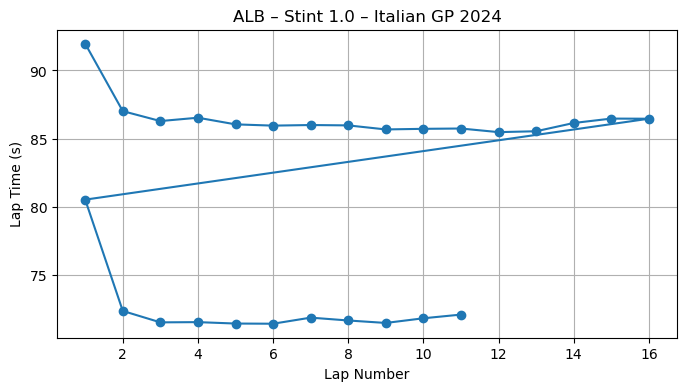

In [1010]:
# Choose a sample outlier
if not potential_outliers.empty:
    example = potential_outliers.iloc[0]
    drv = example['Driver']
    stint = example['Stint']
    year = example['Year']

    # Plot the full stint
    sample = filtered_laps[(filtered_laps['Driver'] == drv) &
                           (filtered_laps['Stint'] == stint) &
                           (filtered_laps['Year'] == year)]

    plt.figure(figsize=(8, 4))
    plt.plot(sample['LapNumber'], sample['LapTimeSeconds'], marker='o')
    plt.title(f"{drv} – Stint {stint} – Italian GP {year}")
    plt.xlabel("Lap Number")
    plt.ylabel("Lap Time (s)")
    plt.grid(True)
    plt.show()

#### Shift from filtering stint to lap outliers

In [1011]:
# Set a spike threshold (e.g., +10 sec delta from previous lap)
spike_threshold = 10.0

# Reuse laps_with_deltas from before
spiked_laps = laps_with_deltas[laps_with_deltas['LapDelta'] > spike_threshold]

# Drop just those laps from the main dataset
filtered_cleaned_laps = filtered_laps[~filtered_laps.index.isin(spiked_laps.index)]

print(f"Laps before cleaning spikes: {len(filtered_laps)}")
print(f"Laps after cleaning spikes:  {len(filtered_cleaned_laps)}")

Laps before cleaning spikes: 6441
Laps after cleaning spikes:  5709


#### Add weather data

In [1012]:
def enrich_with_weather(laps_df, sessions):
    enriched = []

    for session in sessions:
        weather_df = session.weather_data.copy()
        weather_df['Time'] = pd.to_timedelta(weather_df['Time'])  # ensure proper type

        # Match weather per lap
        session_laps = laps_df[laps_df['Year'] == session.date.year]
        session_laps = session_laps.copy()
        session_laps['Time'] = session_laps['LapStartTime'].dt.total_seconds()

        # Convert weather time to seconds to merge
        weather_df['WeatherTime'] = weather_df['Time'].dt.total_seconds()

        # Merge each lap with nearest weather row (on absolute time delta)
        session_laps = pd.merge_asof(
            session_laps.sort_values('Time'),
            weather_df.sort_values('WeatherTime'),
            left_on='Time',
            right_on='WeatherTime',
            direction='nearest',
            tolerance=60  # 1 minute
        )

        enriched.append(session_laps)

    return pd.concat(enriched, ignore_index=True)

In [1013]:
# Run the weather enrichment
filtered_laps_with_weather = enrich_with_weather(filtered_cleaned_laps, sessions)

In [1014]:
filtered_laps_with_weather.shape

(11418, 44)

In [1015]:
filtered_laps_with_weather.columns

Index(['Time_x', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'LapCount',
       'LapTimeSeconds', 'Time_y', 'AirTemp', 'Humidity', 'Pressure',
       'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'WeatherTime'],
      dtype='object')

#### Add telemetry data aggregated per lap

In [1016]:
def aggregate_telemetry(session, laps_df):
    all_features = []

    # Filter laps for this session year
    session_laps = laps_df[laps_df['Year'] == session.date.year]

    for _, lap_row in session_laps.iterrows():
        try:
            lap = session.laps[
                (session.laps['Driver'] == lap_row['Driver']) &
                (session.laps['LapNumber'] == lap_row['LapNumber'])
            ].iloc[0]

            telemetry = lap.get_car_data().add_distance()

            # Aggregate telemetry stats
            features = {
                'Driver': lap_row['Driver'],
                'LapNumber': lap_row['LapNumber'],
                'Stint': lap_row['Stint'],
                'Year': lap_row['Year'],
                'Speed_Mean': telemetry['Speed'].mean(),
                'Speed_Max': telemetry['Speed'].max(),
                'Speed_Std': telemetry['Speed'].std(),
                'RPM_Mean': telemetry['RPM'].mean(),
                'Throttle_Mean': telemetry['Throttle'].mean(),
                'Throttle_Std': telemetry['Throttle'].std(),
                'Brake_Mean': telemetry['Brake'].mean(),
                'Gear_Mean': telemetry['nGear'].mean(),
                'Distance_Total': telemetry['Distance'].max(),  # for per-segment modelling
                'DRS_active_pct': telemetry['DRS'].mean() if 'DRS' in telemetry else 0
            }

            all_features.append(features)

        except (IndexError, AttributeError, KeyError):
            continue  # Skip if data missing

    return pd.DataFrame(all_features)

In [1017]:
# Loop through each session and aggregate telemetry
telemetry_agg_dfs = []
for session in sessions:
    telemetry_agg_dfs.append(aggregate_telemetry(session, filtered_laps_with_weather))
    print(f"Aggregated telemetry for {session.date.year}.")

# Combine telemetry features
lap_telemetry_df = pd.concat(telemetry_agg_dfs, ignore_index=True)

Aggregated telemetry for 2022.
Aggregated telemetry for 2022.
Aggregated telemetry for 2023.
Aggregated telemetry for 2023.
Aggregated telemetry for 2024.
Aggregated telemetry for 2024.


In [1018]:
lap_telemetry_df.shape

(19886, 14)

In [1019]:
lap_telemetry_df.columns

Index(['Driver', 'LapNumber', 'Stint', 'Year', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'Gear_Mean', 'Distance_Total', 'DRS_active_pct'],
      dtype='object')

In [1020]:
# Merge telemetry features into laps+weather
final_lap_df = pd.merge(
    filtered_laps_with_weather,
    lap_telemetry_df,
    on=['Driver', 'LapNumber', 'Stint', 'Year'],
    how='inner'
)

In [1021]:
final_lap_df.shape

(42956, 54)

In [1022]:
final_lap_df.columns

Index(['Time_x', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'LapCount',
       'LapTimeSeconds', 'Time_y', 'AirTemp', 'Humidity', 'Pressure',
       'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'WeatherTime',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct'],
      dtype='object')

In [1023]:
final_lap_df.head()

,Time_x,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Speed_Mean,Speed_Max,Speed_Std,RPM_Mean,Throttle_Mean,Throttle_Std,Brake_Mean,Gear_Mean,Distance_Total,DRS_active_pct
0,3733.798,STR,18,0 days 00:01:19.383000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.564000,...,208.723464,323.0,80.000729,10063.888268,63.821229,42.078310,0.00000,5.505587,5533.805278,1.0
1,3733.798,STR,18,0 days 00:01:19.383000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.564000,...,208.723464,323.0,80.000729,10063.888268,63.821229,42.078310,0.00000,5.505587,5533.805278,1.0
2,3733.798,STR,18,0 days 00:01:19.383000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.564000,...,208.723464,323.0,80.000729,10063.888268,63.821229,42.078310,0.00000,5.505587,5533.805278,1.0
3,3733.798,STR,18,0 days 00:01:19.383000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.564000,...,208.723464,323.0,80.000729,10063.888268,63.821229,42.078310,0.00000,5.505587,5533.805278,1.0
4,3733.798,STR,18,0 days 00:01:19.383000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.564000,...,192.993355,308.0,69.162128,10038.019934,62.189369,43.413754,0.23588,4.986711,4246.909167,1.0


In [1024]:
final_lap_df[final_lap_df['Driver']=='VER']

,Time_x,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Speed_Mean,Speed_Max,Speed_Std,RPM_Mean,Throttle_Mean,Throttle_Std,Brake_Mean,Gear_Mean,Distance_Total,DRS_active_pct
484,3733.798,VER,1,0 days 00:01:12.722000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.134000,...,217.158358,316.0,78.673365,10427.568915,70.214076,42.652818,0.199413,5.363636,5499.228611,1.0
485,3733.798,VER,1,0 days 00:01:12.722000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.134000,...,217.158358,316.0,78.673365,10427.568915,70.214076,42.652818,0.199413,5.363636,5499.228611,1.0
486,3733.798,VER,1,0 days 00:01:12.722000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.134000,...,217.158358,316.0,78.673365,10427.568915,70.214076,42.652818,0.199413,5.363636,5499.228611,1.0
487,3733.798,VER,1,0 days 00:01:12.722000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.134000,...,217.158358,316.0,78.673365,10427.568915,70.214076,42.652818,0.199413,5.363636,5499.228611,1.0
488,3733.798,VER,1,0 days 00:01:12.722000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.134000,...,206.720000,293.0,65.340586,10487.720000,70.810909,41.986710,0.167273,5.010909,4157.711389,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42847,8284.748,VER,1,0 days 00:01:08.072000,70.0,4.0,NaT,NaT,0 days 00:00:17.214000,0 days 00:00:30.512000,...,227.570866,299.0,61.374063,10374.035433,71.027559,41.802321,0.188976,5.877953,4281.094167,0.0
42916,8352.820,VER,1,0 days 00:01:08.518000,71.0,4.0,NaT,NaT,0 days 00:00:17.243000,0 days 00:00:30.640000,...,227.785156,299.0,59.408826,10419.929688,71.722656,42.052036,0.175781,5.835938,4275.673056,0.0
42917,8352.820,VER,1,0 days 00:01:08.518000,71.0,4.0,NaT,NaT,0 days 00:00:17.243000,0 days 00:00:30.640000,...,227.785156,299.0,59.408826,10419.929688,71.722656,42.052036,0.175781,5.835938,4275.673056,0.0
42918,8352.820,VER,1,0 days 00:01:08.518000,71.0,4.0,NaT,NaT,0 days 00:00:17.243000,0 days 00:00:30.640000,...,227.785156,299.0,59.408826,10419.929688,71.722656,42.052036,0.175781,5.835938,4275.673056,0.0


#### Filter features for model use

In [1025]:
# Check if there was rain
final_lap_df['Rainfall'].value_counts()

Rainfall
False    42650
Name: count, dtype: int64

In [1026]:
# Find scrubbed tyres
freshtyre_ct_df = final_lap_df[
                      (final_lap_df['LapNumber'] == 1) &
                      (final_lap_df['FreshTyre'] == False) &
                      (final_lap_df['Stint'] == 1)
                  ]

freshtyre_ct_df.shape

# Scrubbed tyres heat up faster -> Better grip in first few laps
# Teams have a limited number of sets per compound across the weekend
# Keep 'FreshTyre' feature

(276, 54)

In [1027]:
features_to_keep = [
    # Context
    'Driver', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'FreshTyre', 'Compound', 'Race', 'LapCount',
    
    # Weather
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Pressure', 'Rainfall',

    # Telemetry Aggregates
    'Speed_Mean', 'Speed_Max', 'Speed_Std',
    'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
    'RPM_Mean', 'Gear_Mean', 'DRS_active_pct',

    # Meta - Strategy Features
    'Team', 'Position',

    # For label calculation:
    'LapTimeSeconds'
]

In [1028]:
final_df = final_lap_df[features_to_keep]

In [1029]:
final_df_copy = final_lap_df[features_to_keep].copy()

In [1030]:
final_df.shape

(42956, 27)

In [1031]:
final_df.columns

Index(['Driver', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'FreshTyre',
       'Compound', 'Race', 'LapCount', 'TrackTemp', 'AirTemp', 'Humidity',
       'WindSpeed', 'Pressure', 'Rainfall', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'RPM_Mean',
       'Gear_Mean', 'DRS_active_pct', 'Team', 'Position', 'LapTimeSeconds'],
      dtype='object')

#### Visualize 'LapTimeSeconds' for Label Engineering

In [1032]:
# Find the best lap number by driver, stint, and year
best_lap_indices = (
    final_df.groupby(['Driver', 'Stint', 'Year'])['LapTimeSeconds']
    .idxmin()
)

best_laps = final_df.loc[best_lap_indices, ['Driver', 'Stint', 'Year', 'LapNumber', 'LapTimeSeconds']]
best_laps.rename(columns={'LapNumber': 'BestLapNumber'}, inplace=True)

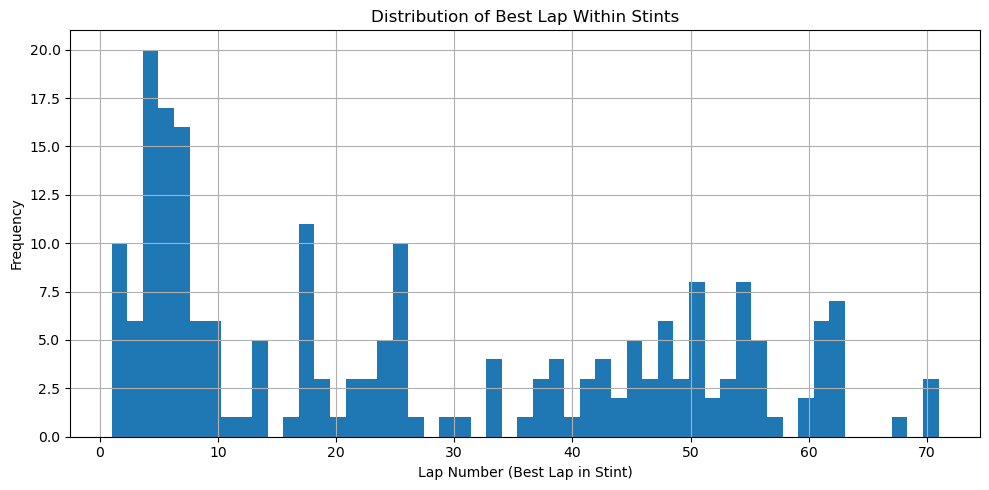

In [1033]:
# Plot best lap distribution
plt.figure(figsize=(10, 5))
plt.hist(best_laps['BestLapNumber'], bins=53)
plt.title('Distribution of Best Lap Within Stints')
plt.xlabel('Lap Number (Best Lap in Stint)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Calculate Lap Time Fall Off

In [1034]:
def compute_lap_falloff(df):
    df = df.copy()
    df['LapTimeFalloff'] = None

    for (driver, stint, year), group in df.groupby(['Driver', 'Stint', 'Year']):
        group = group.sort_values('LapNumber')
        first_lap_time = group['LapTimeSeconds'].iloc[0]
        df.loc[group.index, 'LapTimeFalloff'] = group['LapTimeSeconds'] - first_lap_time

    return df

In [1035]:
final_df = compute_lap_falloff(final_df)

#### Apply Fuel Correction

In [1036]:
# Use Italian Grand Prix for fuel burn assumption
FUEL_BURN_PER_LAP = 1.82  # kg
FUEL_TIME_GAIN_PER_KG = 0.03  # sec/kg

def apply_fuel_correction(df):
    df = df.copy()
    
    # Estimate fuel burned since start of stint
    df['FuelBurned'] = (df['LapNumber'] - df.groupby(['Driver', 'Stint', 'Year'])['LapNumber'].transform('min')) * FUEL_BURN_PER_LAP
    
    # Adjust lap time falloff by subtracting the performance gain due to reduced weight
    df['LapTimeFalloff_FuelAdjusted'] = df['LapTimeFalloff'] - (df['FuelBurned'] * FUEL_TIME_GAIN_PER_KG)
    
    return df

In [1037]:
final_df = apply_fuel_correction(final_df)

In [1038]:
final_df[final_df['Driver']=='VER'][['LapNumber', 'LapTimeSeconds', 'LapTimeFalloff', 'FuelBurned', 'LapTimeFalloff_FuelAdjusted']].head(10)

,LapNumber,LapTimeSeconds,LapTimeFalloff,FuelBurned,LapTimeFalloff_FuelAdjusted
484,1.0,72.722,0.0,0.0,0.0
485,1.0,72.722,0.0,0.0,0.0
486,1.0,72.722,0.0,0.0,0.0
487,1.0,72.722,0.0,0.0,0.0
488,1.0,72.722,0.0,0.0,0.0
489,1.0,72.722,0.0,0.0,0.0
490,1.0,72.722,0.0,0.0,0.0
491,1.0,72.722,0.0,0.0,0.0
492,1.0,90.827,18.105,0.0,18.105
493,1.0,90.827,18.105,0.0,18.105


In [1039]:
# First lap used for warmup
# Use average time of laps 2-4 for baseline

def compute_smoothed_fuel_adjusted_falloff(df):
    df = df.copy()

    df['FuelBurned'] = 0.0
    df['LapTimeFalloff'] = None
    df['LapTimeFalloff_FuelAdjusted'] = None

    for (driver, stint, year), group in df.groupby(['Driver', 'Stint', 'Year']):
        group = group.sort_values('LapNumber')
        
        lap_nums = group['LapNumber'].values
        lap_times = group['LapTimeSeconds'].values

        # Estimate fuel burned since start of stint
        fuel_burned = (lap_nums - lap_nums[0]) * FUEL_BURN_PER_LAP
        df.loc[group.index, 'FuelBurned'] = fuel_burned

        # Use average of laps 2–4 in stint (relative to stint start)
        rel_lap_offset = lap_nums - lap_nums[0]
        early_indices = (rel_lap_offset >= 1) & (rel_lap_offset <= 3)

        if early_indices.sum() >= 1:
            ref_lap_time = lap_times[early_indices].mean()
        else:
            ref_lap_time = lap_times[0]  # fallback to lap 1

        # Raw fall-off
        raw_falloff = lap_times - ref_lap_time

        # Fuel-adjusted fall-off
        fuel_adjusted = raw_falloff - (fuel_burned * FUEL_TIME_GAIN_PER_KG)

        df.loc[group.index, 'LapTimeFalloff'] = raw_falloff
        df.loc[group.index, 'LapTimeFalloff_FuelAdjusted'] = fuel_adjusted

    return df

In [1040]:
final_df = compute_smoothed_fuel_adjusted_falloff(final_df)

In [1041]:
final_df.columns

Index(['Driver', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'FreshTyre',
       'Compound', 'Race', 'LapCount', 'TrackTemp', 'AirTemp', 'Humidity',
       'WindSpeed', 'Pressure', 'Rainfall', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'RPM_Mean',
       'Gear_Mean', 'DRS_active_pct', 'Team', 'Position', 'LapTimeSeconds',
       'LapTimeFalloff', 'FuelBurned', 'LapTimeFalloff_FuelAdjusted'],
      dtype='object')

In [1042]:
final_df[final_df['Driver']=='VER'][['LapNumber', 'LapTimeSeconds', 'LapTimeFalloff', 'FuelBurned', 'LapTimeFalloff_FuelAdjusted']].head(10)

,LapNumber,LapTimeSeconds,LapTimeFalloff,FuelBurned,LapTimeFalloff_FuelAdjusted
484,1.0,72.722,-2.810167,0.0,-2.810167
485,1.0,72.722,-2.810167,0.0,-2.810167
486,1.0,72.722,-2.810167,0.0,-2.810167
487,1.0,72.722,-2.810167,0.0,-2.810167
488,1.0,72.722,-2.810167,0.0,-2.810167
489,1.0,72.722,-2.810167,0.0,-2.810167
490,1.0,72.722,-2.810167,0.0,-2.810167
491,1.0,72.722,-2.810167,0.0,-2.810167
492,1.0,90.827,15.294833,0.0,15.294833
493,1.0,90.827,15.294833,0.0,15.294833


In [1043]:
def plot_fuel_adjusted_falloff(driver, year):
    df = final_df[(final_df['Driver'] == driver) & (final_df['Year'] == year)].copy()
    df = df.sort_values(['Stint', 'LapNumber'])

    plt.figure(figsize=(10, 5))

    for stint, group in df.groupby('Stint'):
        plt.plot(group['LapNumber'], group['LapTimeFalloff_FuelAdjusted'],
                 marker='o', label=f'Stint {int(stint)}')

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f"{driver} Fuel-Adjusted Lap Time Fall-Off – {year}")
    plt.xlabel("Lap Number")
    plt.ylabel("Fuel-Adjusted Fall-Off (s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

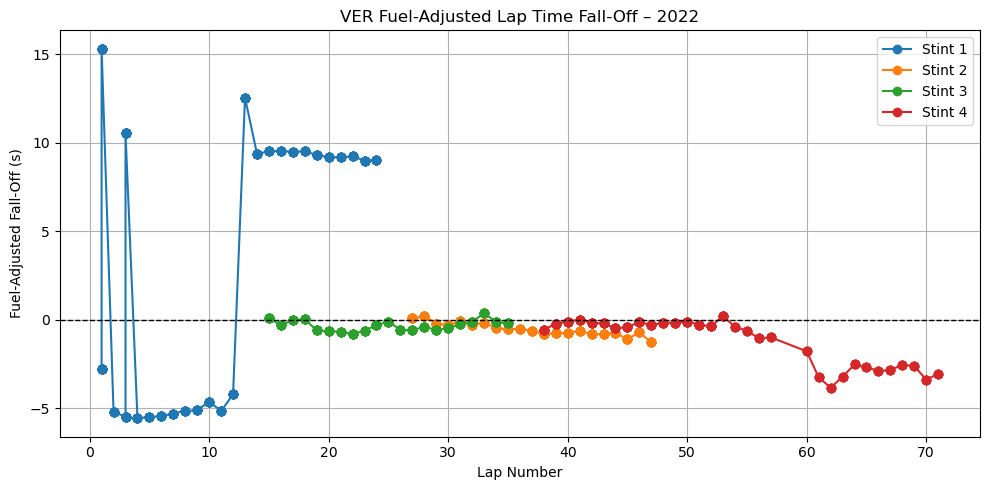

In [1044]:
# Visualize VER in 2022
plot_fuel_adjusted_falloff('VER', 2022)

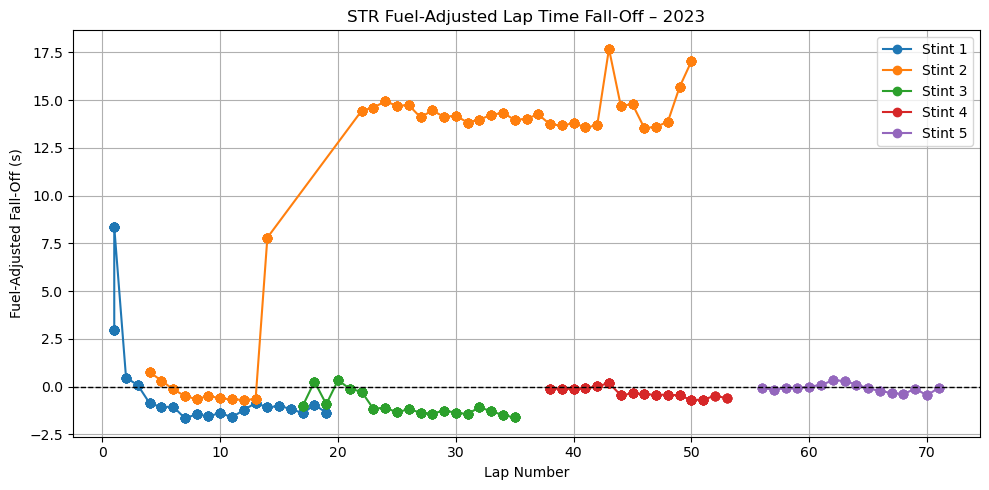

In [1045]:
# Visualize STR in 2023
plot_fuel_adjusted_falloff('STR', 2023)

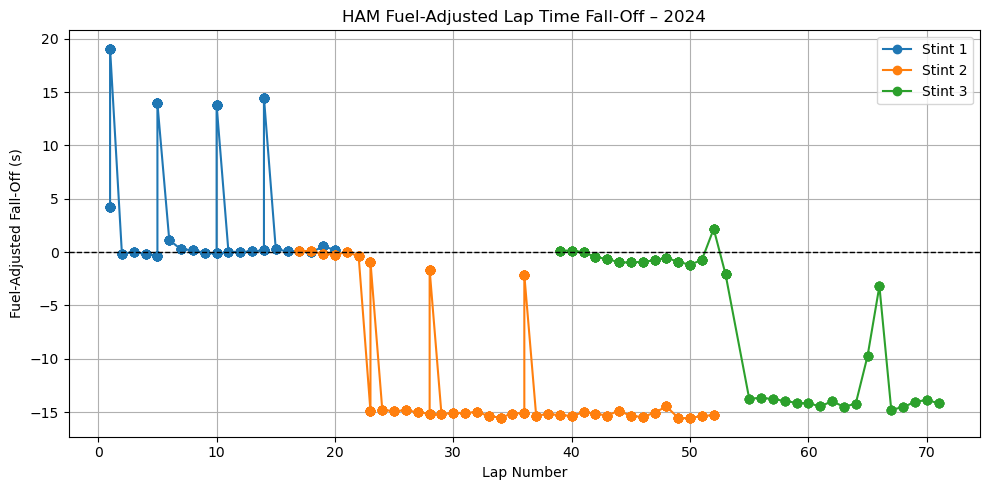

In [1046]:
# Visualize HAM in 2024
plot_fuel_adjusted_falloff('HAM', 2024)

Fuel adjusted lap time fall off is not a good label for tyre wear.<br>
Pivot to including 'TyreLife' in the target.

In [1047]:
final_df['TyreLife'].describe()

count    42956.000000
mean        13.879411
std          9.657213
min          1.000000
25%          6.000000
50%         12.000000
75%         19.000000
max         63.000000
Name: TyreLife, dtype: float64

In [1048]:
final_df[
    (final_df['Driver'] == 'VER') &
    (final_df['Year'] == 2022)
][['Stint', 'TyreLife', 'LapNumber', 'Compound', 'FreshTyre']]

,Stint,TyreLife,LapNumber,Compound,FreshTyre
484,1.0,1.0,1.0,MEDIUM,True
485,1.0,1.0,1.0,MEDIUM,True
486,1.0,1.0,1.0,MEDIUM,True
487,1.0,1.0,1.0,MEDIUM,True
488,1.0,1.0,1.0,MEDIUM,True
...,...,...,...,...,...
13491,4.0,34.0,70.0,MEDIUM,True
13552,4.0,35.0,71.0,MEDIUM,True
13553,4.0,35.0,71.0,MEDIUM,True
13554,4.0,35.0,71.0,MEDIUM,True


In [1049]:
final_df[
    (final_df['Driver'] == 'STR') &
    (final_df['Year'] == 2022)
][['Stint', 'TyreLife', 'LapNumber', 'Compound', 'FreshTyre']]

,Stint,TyreLife,LapNumber,Compound,FreshTyre
0,1.0,3.0,1.0,MEDIUM,False
1,1.0,3.0,1.0,MEDIUM,False
2,1.0,3.0,1.0,MEDIUM,False
3,1.0,3.0,1.0,MEDIUM,False
4,1.0,3.0,1.0,MEDIUM,False
...,...,...,...,...,...
13519,3.0,42.0,69.0,MEDIUM,False
13584,3.0,43.0,70.0,MEDIUM,False
13585,3.0,43.0,70.0,MEDIUM,False
13586,3.0,43.0,70.0,MEDIUM,False


In [1050]:
final_df_copy.columns

Index(['Driver', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'FreshTyre',
       'Compound', 'Race', 'LapCount', 'TrackTemp', 'AirTemp', 'Humidity',
       'WindSpeed', 'Pressure', 'Rainfall', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'RPM_Mean',
       'Gear_Mean', 'DRS_active_pct', 'Team', 'Position', 'LapTimeSeconds'],
      dtype='object')

In [1052]:
final_df_copy['Compound'].value_counts()

Compound
HARD      23616
MEDIUM    18372
SOFT        968
Name: count, dtype: int64

In [1053]:
# Filter out Intermediate tires
# final_df_copy = final_df_copy[final_df_copy['Compound'] != 'INTERMEDIATE']
# final_df_copy['Compound'].value_counts()

In [1054]:
compound_thresholds_by_race = {
    'Italian Grand Prix' : {
        'SOFT':   {'low': 4,  'high': 10},
        'MEDIUM': {'low': 6,  'high': 14},
        'HARD':   {'low': 8,  'high': 18}
    },
    'Austrian Grand Prix' : {
        'SOFT':   {'low': 6,  'high': 12},
        'MEDIUM': {'low': 8,  'high': 16},
        'HARD':   {'low': 10,  'high': 20}
    }
}

In [1056]:
soft_low_ratio = 4 / 53
soft_high_ratio = 10 / 53
medium_low_ratio = 6 / 53
medium_high_ratio = 14 / 53
hard_low_ratio = 8 / 53
hard_high_ratio = 18 / 53

In [1060]:
def classify_degradation_multi(row):
    race = row['Race']
    lap_count = row['LapCount']
    compound = row['Compound'].upper()
    tyrelife = row['TyreLife']

    compound_thresholds = compound_thresholds_by_race[race]

    # compound_thresholds_for_race = {
    #     'SOFT':   {'low': soft_low_ratio * lap_count,  'high': soft_high_ratio * lap_count},
    #     'MEDIUM': {'low': medium_low_ratio * lap_count,  'high': medium_high_ratio * lap_count},
    #     'HARD':   {'low': hard_low_ratio * lap_count,  'high': hard_high_ratio * lap_count}
    # }

    thresholds = compound_thresholds[compound]
    
    # High degradation: old tyre
    if tyrelife >= thresholds['high']:
        return 'high'

    # Low degradation: young tyre
    elif tyrelife <= thresholds['low']:
        return 'low'

    # Medium otherwise
    else:
        return 'medium'

In [1061]:
def classify_degradation(row):
    compound = row['Compound'].upper()
    tyrelife = row['TyreLife']

    thresholds = compound_thresholds[compound]

    # High degradation: old tyre
    if tyrelife >= thresholds['high']:
        return 'high'

    # Low degradation: young tyre
    elif tyrelife <= thresholds['low']:
        return 'low'

    # Medium otherwise
    else:
        return 'medium'

In [1062]:
final_df_copy['DegradationClass'] = final_df_copy.apply(classify_degradation_multi, axis=1)

In [1063]:
final_df_copy['DegradationClass'].value_counts()

DegradationClass
low       15052
high      14324
medium    13580
Name: count, dtype: int64

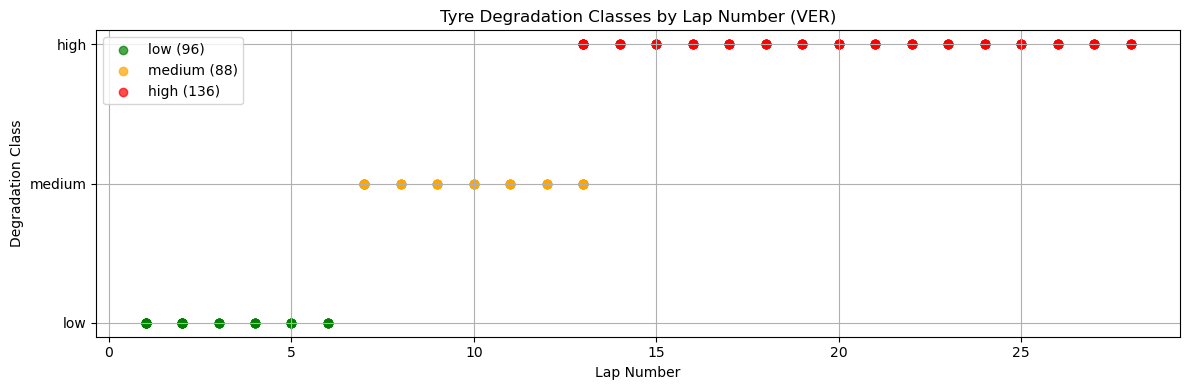

In [1064]:
# Filter for one driver, year, and race for clarity
driver_df = final_df_copy[
                (final_df['Driver'] == 'STR') &
                (final_df['Year'] == 2022) &
                (final_df['Stint'] == 1)
            ]

# Set colors for each class
color_map = {'low': 'green', 'medium': 'orange', 'high': 'red'}

plt.figure(figsize=(12, 4))

# Plot each class
for cls in ['low', 'medium', 'high']:
    subset = driver_df[driver_df['DegradationClass'] == cls]
    plt.scatter(subset['LapNumber'], [cls]*len(subset), 
                label=f'{cls} ({len(subset)})', 
                color=color_map[cls], alpha=0.7)

plt.xlabel('Lap Number')
plt.ylabel('Degradation Class')
plt.title('Tyre Degradation Classes by Lap Number (VER)')
plt.yticks(['low', 'medium', 'high'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Classification or Regression:
Binned 'TyreLife' or number

In [1065]:
# TyreLife-based label
final_df_copy.columns

Index(['Driver', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'FreshTyre',
       'Compound', 'Race', 'LapCount', 'TrackTemp', 'AirTemp', 'Humidity',
       'WindSpeed', 'Pressure', 'Rainfall', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'RPM_Mean',
       'Gear_Mean', 'DRS_active_pct', 'Team', 'Position', 'LapTimeSeconds',
       'DegradationClass'],
      dtype='object')

#### Clean Feature Set

In [1066]:
# Select only weather-related columns
weather_cols = ['TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Pressure']
weather_stats = final_df[weather_cols].describe().T

# Add a column for standard deviation as % of mean (to assess variation)
weather_stats['% StdDev of Mean'] = (weather_stats['std'] / weather_stats['mean']) * 100

# Display the stats
weather_stats[['mean', 'std', 'min', 'max', '% StdDev of Mean']]

,mean,std,min,max,% StdDev of Mean
TrackTemp,40.530030,6.549486,28.5,51.7,16.159588
AirTemp,27.292633,4.304113,19.8,33.9,15.770239
Humidity,37.643236,7.496631,30.0,56.0,19.914949
WindSpeed,1.429257,0.522808,0.0,3.9,36.579042
Pressure,965.461491,30.228360,932.6,1000.5,3.130975


In [1067]:
# Filter out rows where Weather doesn't exist (NaN)
final_df_copy.dropna(inplace=True)
final_df_copy.reset_index(drop=True, inplace=True)

In [1068]:
# Filter out rows with Rainfall
final_df_copy = final_df_copy[final_df_copy['Rainfall'] == False]


In [1069]:
# Remove rainfall column
final_df_copy = final_df_copy.drop(columns=['Rainfall'])

In [1070]:
# Remove LapCount column
final_df_copy = final_df_copy.drop(columns=['LapCount'])

In [1071]:
# Remove weather data for single track
# final_df_copy = final_df_copy.drop(columns=weather_cols)

In [1072]:
# Remove TyreLife, LapNumber to prevent target leakage
final_df_copy = final_df_copy.drop(columns=['TyreLife', 'LapNumber'])

In [1073]:
# Remove Team to reduce redundancy with Driver feature
# final_df_copy = final_df_copy.drop(columns=['Team'])

In [1074]:
# Years 2022-2024 are of the same car generation (with minor tweaks). Drop to reduce noise
final_df_copy = final_df_copy.drop(columns=['Year'])

In [1075]:
# Could bias model toward track traffic patterns
final_df_copy = final_df_copy.drop(columns=['Position'])

In [1076]:
final_df_copy.columns

Index(['Driver', 'Stint', 'FreshTyre', 'Compound', 'Race', 'TrackTemp',
       'AirTemp', 'Humidity', 'WindSpeed', 'Pressure', 'Speed_Mean',
       'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'RPM_Mean', 'Gear_Mean', 'DRS_active_pct', 'Team', 'LapTimeSeconds',
       'DegradationClass'],
      dtype='object')

Why these features?
- Driver: Needed to model driver tendencies
- Stint: Adds context across the race
- FreshTyre: Important tyre wear signal
- Compound: Critical for degradation model
- (Telemetry features): Driving behavior signal
- LapTimeSeconds: Useful signal of performance
- DegradationClass: Target label based on TyreLife

---

#### Encode Categorical Features

In [1077]:
df = final_df_copy.copy()

In [1078]:
# Apply custom mapping for label encoding
custom_label_map = {'low': 0, 'medium': 1, 'high': 2}
df['DegradationClass'] = df['DegradationClass'].map(custom_label_map)

print(df['DegradationClass'].value_counts())

DegradationClass
0    15048
2    14050
1    13552
Name: count, dtype: int64


In [1079]:
# One-hot encoding
categorical_cols = ['Driver', 'Team', 'Compound', 'FreshTyre', 'Race']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Encoded shape:", df_encoded.shape)
print("Encoded columns:", df_encoded.columns.tolist())

Encoded shape: (42650, 62)
Encoded columns: ['Stint', 'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Pressure', 'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'RPM_Mean', 'Gear_Mean', 'DRS_active_pct', 'LapTimeSeconds', 'DegradationClass', 'Driver_ALB', 'Driver_ALO', 'Driver_BOT', 'Driver_COL', 'Driver_DEV', 'Driver_GAS', 'Driver_HAM', 'Driver_HUL', 'Driver_LAT', 'Driver_LAW', 'Driver_LEC', 'Driver_MAG', 'Driver_MSC', 'Driver_NOR', 'Driver_OCO', 'Driver_PER', 'Driver_PIA', 'Driver_RIC', 'Driver_RUS', 'Driver_SAI', 'Driver_SAR', 'Driver_STR', 'Driver_TSU', 'Driver_VER', 'Driver_VET', 'Driver_ZHO', 'Team_Alfa Romeo', 'Team_AlphaTauri', 'Team_Alpine', 'Team_Aston Martin', 'Team_Ferrari', 'Team_Haas F1 Team', 'Team_Kick Sauber', 'Team_McLaren', 'Team_Mercedes', 'Team_RB', 'Team_Red Bull Racing', 'Team_Williams', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'FreshTyre_False', 'FreshTyre_True', 'Race_Austrian Grand Prix', 'Race_Italian Grand

In [1080]:
df_encoded.head()

,Stint,TrackTemp,AirTemp,Humidity,WindSpeed,Pressure,Speed_Mean,Speed_Max,Speed_Std,Throttle_Mean,...,Team_RB,Team_Red Bull Racing,Team_Williams,Compound_HARD,Compound_MEDIUM,Compound_SOFT,FreshTyre_False,FreshTyre_True,Race_Austrian Grand Prix,Race_Italian Grand Prix
0,1.0,43.5,27.8,32.0,0.4,993.5,208.723464,323.0,80.000729,63.821229,...,False,False,False,False,True,False,True,False,True,False
1,1.0,43.5,27.8,32.0,0.4,993.5,208.723464,323.0,80.000729,63.821229,...,False,False,False,False,True,False,True,False,True,False
2,1.0,43.5,27.8,32.0,0.4,993.5,208.723464,323.0,80.000729,63.821229,...,False,False,False,False,True,False,True,False,True,False
3,1.0,43.5,27.8,32.0,0.4,993.5,208.723464,323.0,80.000729,63.821229,...,False,False,False,False,True,False,True,False,True,False
4,1.0,43.5,27.8,32.0,0.4,993.5,192.993355,308.0,69.162128,62.189369,...,False,False,False,False,True,False,True,False,True,False


In [1081]:
df_encoded.columns

Index(['Stint', 'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Pressure',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'Brake_Mean', 'RPM_Mean', 'Gear_Mean', 'DRS_active_pct',
       'LapTimeSeconds', 'DegradationClass', 'Driver_ALB', 'Driver_ALO',
       'Driver_BOT', 'Driver_COL', 'Driver_DEV', 'Driver_GAS', 'Driver_HAM',
       'Driver_HUL', 'Driver_LAT', 'Driver_LAW', 'Driver_LEC', 'Driver_MAG',
       'Driver_MSC', 'Driver_NOR', 'Driver_OCO', 'Driver_PER', 'Driver_PIA',
       'Driver_RIC', 'Driver_RUS', 'Driver_SAI', 'Driver_SAR', 'Driver_STR',
       'Driver_TSU', 'Driver_VER', 'Driver_VET', 'Driver_ZHO',
       'Team_Alfa Romeo', 'Team_AlphaTauri', 'Team_Alpine',
       'Team_Aston Martin', 'Team_Ferrari', 'Team_Haas F1 Team',
       'Team_Kick Sauber', 'Team_McLaren', 'Team_Mercedes', 'Team_RB',
       'Team_Red Bull Racing', 'Team_Williams', 'Compound_HARD',
       'Compound_MEDIUM', 'Compound_SOFT', 'FreshTyre_False', 'FreshTyre_T

In [1082]:
numeric_cols = [
    'Stint', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
    'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'RPM_Mean',
    'Gear_Mean', 'DRS_active_pct', 'LapTimeSeconds',
    'TrackTemp', 'AirTemp', 'Humidity', 'WindSpeed', 'Pressure'
]

In [1083]:
# Create a copy to avoid modifying original
X = df_encoded.drop(columns=['DegradationClass'])
y = df_encoded['DegradationClass']

# Standardize numeric columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(X[numeric_cols].describe())

              Stint    Speed_Mean     Speed_Max     Speed_Std  Throttle_Mean  \
count  4.265000e+04  4.265000e+04  4.265000e+04  4.265000e+04   4.265000e+04   
mean   5.331153e-17  1.299469e-15 -1.487392e-15 -8.263287e-17   1.912551e-15   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   1.000012e+00   
min   -1.229019e+00 -6.759316e+00 -7.080859e+00 -6.007214e+00  -8.871674e+00   
25%   -1.229019e+00 -5.164788e-01 -9.237286e-01 -7.907123e-01  -4.452823e-01   
50%   -1.834678e-01 -2.236765e-01  3.271880e-02 -1.163540e-01   9.018113e-02   
75%    8.620830e-01  8.307548e-01  8.696103e-01  7.064820e-01   5.924207e-01   
max    2.953184e+00  1.820026e+00  2.782505e+00  6.137564e+00   1.961855e+00   

       Throttle_Std    Brake_Mean      RPM_Mean     Gear_Mean  DRS_active_pct  \
count  4.265000e+04  4.265000e+04  4.265000e+04  4.265000e+04    4.265000e+04   
mean   1.146198e-16  5.037940e-16 -4.531480e-17  9.439473e-16    2.732216e-17   
std    1.000012e+00  1.000012e+00  1

In [1084]:
X.head()

,Stint,TrackTemp,AirTemp,Humidity,WindSpeed,Pressure,Speed_Mean,Speed_Max,Speed_Std,Throttle_Mean,...,Team_RB,Team_Red Bull Racing,Team_Williams,Compound_HARD,Compound_MEDIUM,Compound_SOFT,FreshTyre_False,FreshTyre_True,Race_Austrian Grand Prix,Race_Italian Grand Prix
0,-1.229019,0.453471,0.117881,-0.752778,-1.96873,0.927567,-0.971246,0.391387,1.690157,-1.172676,...,False,False,False,False,True,False,True,False,True,False
1,-1.229019,0.453471,0.117881,-0.752778,-1.96873,0.927567,-0.971246,0.391387,1.690157,-1.172676,...,False,False,False,False,True,False,True,False,True,False
2,-1.229019,0.453471,0.117881,-0.752778,-1.96873,0.927567,-0.971246,0.391387,1.690157,-1.172676,...,False,False,False,False,True,False,True,False,True,False
3,-1.229019,0.453471,0.117881,-0.752778,-1.96873,0.927567,-0.971246,0.391387,1.690157,-1.172676,...,False,False,False,False,True,False,True,False,True,False
4,-1.229019,0.453471,0.117881,-0.752778,-1.96873,0.927567,-1.929405,-0.505283,0.037819,-1.473895,...,False,False,False,False,True,False,True,False,True,False


#### Split Data

In [1085]:
# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (29871, 61)
Validation: (6381, 61)
Test: (6398, 61)


#### Train Baseline Using RandomForest

In [1086]:
# Train basic Random Forest
rf_base = RandomForestClassifier(random_state=111)
rf_base.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf_base.predict(X_val)

# Evaluate performance
print("Baseline Model Performance (Random Forest):\n")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=['low', 'medium', 'high']))

Baseline Model Performance (Random Forest):

[[2199   50    2]
 [  42 1957   29]
 [   4   27 2071]]
              precision    recall  f1-score   support

         low       0.98      0.98      0.98      2251
      medium       0.96      0.96      0.96      2028
        high       0.99      0.99      0.99      2102

    accuracy                           0.98      6381
   macro avg       0.98      0.98      0.98      6381
weighted avg       0.98      0.98      0.98      6381



In [1087]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=54,
    cv=4,
    scoring='accuracy',
    random_state=111,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best RF Params:", rf_search.best_params_)

Fitting 4 folds for each of 54 candidates, totalling 216 fits


/Users/drewcch/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Params: {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}


In [1088]:
# Predict on validation set
y_val_pred_tuned = rf_search.predict(X_val)

# Evaluate performance
print("Tuned Model Performance (Random Forest):\n")
print(confusion_matrix(y_val, y_val_pred_tuned))
print(classification_report(y_val, y_val_pred_tuned, target_names=['low', 'medium', 'high']))

Tuned Model Performance (Random Forest):

[[2207   44    0]
 [  45 1956   27]
 [   3   20 2079]]
              precision    recall  f1-score   support

         low       0.98      0.98      0.98      2251
      medium       0.97      0.96      0.97      2028
        high       0.99      0.99      0.99      2102

    accuracy                           0.98      6381
   macro avg       0.98      0.98      0.98      6381
weighted avg       0.98      0.98      0.98      6381



In [1089]:
# Predict on test set
y_test_pred_tuned = rf_search.predict(X_test)

# Evaluate performance
print("Tuned Model Performance on Test (Random Forest):\n")
print(confusion_matrix(y_test, y_test_pred_tuned))
print(classification_report(y_test, y_test_pred_tuned, target_names=['low', 'medium', 'high']))

Tuned Model Performance on Test (Random Forest):

[[2207   46    4]
 [  35 1971   27]
 [   7   36 2065]]
              precision    recall  f1-score   support

         low       0.98      0.98      0.98      2257
      medium       0.96      0.97      0.96      2033
        high       0.99      0.98      0.98      2108

    accuracy                           0.98      6398
   macro avg       0.98      0.98      0.98      6398
weighted avg       0.98      0.98      0.98      6398



#### Train XGBoost Classifier

In [1090]:
# XGBoost with reasonable default params
xgb_base = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=111
)

xgb_base.fit(X_train, y_train)

# Predict on validation set
y_val_pred_xgb = xgb_base.predict(X_val)

# Evaluate
print("XGBoost Performance:\n")
print(confusion_matrix(y_val, y_val_pred_xgb))
print(classification_report(y_val, y_val_pred_xgb, target_names=['low', 'medium', 'high']))

XGBoost Performance:

[[2161   85    5]
 [  71 1874   83]
 [   4   50 2048]]
              precision    recall  f1-score   support

         low       0.97      0.96      0.96      2251
      medium       0.93      0.92      0.93      2028
        high       0.96      0.97      0.97      2102

    accuracy                           0.95      6381
   macro avg       0.95      0.95      0.95      6381
weighted avg       0.95      0.95      0.95      6381



In [1091]:
# Hyperparameter tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 1],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=50,
    cv=4,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1,
    random_state=111
)

xgb_search.fit(X_train, y_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits


/Users/drewcch/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=4,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=3, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2, 1],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=111, scoring='f1_weighted', verbose=1)

In [1092]:
best_xgb = xgb_search.best_estimator_

# Predict and evaluate on validation set
y_val_pred_xgb_tuned = best_xgb.predict(X_val)

print("Best Parameters:", xgb_search.best_params_)
print("\nTuned XGBoost Performance:\n")
print(confusion_matrix(y_val, y_val_pred_xgb_tuned))
print(classification_report(y_val, y_val_pred_xgb_tuned, target_names=['low', 'medium', 'high']))

Best Parameters: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}

Tuned XGBoost Performance:

[[2236   15    0]
 [  15 2001   12]
 [   2    8 2092]]
              precision    recall  f1-score   support

         low       0.99      0.99      0.99      2251
      medium       0.99      0.99      0.99      2028
        high       0.99      1.00      0.99      2102

    accuracy                           0.99      6381
   macro avg       0.99      0.99      0.99      6381
weighted avg       0.99      0.99      0.99      6381



In [1093]:
# Predict and evaluate on test set
y_test_pred_xgb_tuned = best_xgb.predict(X_test)

print("Best Parameters:", xgb_search.best_params_)
print("\nTuned XGBoost Performance:\n")
print(confusion_matrix(y_test, y_test_pred_xgb_tuned))
print(classification_report(y_test, y_test_pred_xgb_tuned, target_names=['low', 'medium', 'high']))

Best Parameters: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}

Tuned XGBoost Performance:

[[2240   17    0]
 [  11 2014    8]
 [   4   14 2090]]
              precision    recall  f1-score   support

         low       0.99      0.99      0.99      2257
      medium       0.98      0.99      0.99      2033
        high       1.00      0.99      0.99      2108

    accuracy                           0.99      6398
   macro avg       0.99      0.99      0.99      6398
weighted avg       0.99      0.99      0.99      6398

